# Trực Quan Hóa Dữ Liệu & Kết Quả Mô Hình CNN-SVM

Notebook này bao gồm:
1. **Ảnh mẫu theo từng lớp** (grid 10 chữ số)
2. **Phân bố lớp** (Bar chart + Pie chart)
3. **Confusion Matrix heatmap**
4. **Trực quan hóa dự đoán** (đúng & sai)
5. **t-SNE** – không gian đặc trưng CNN (nâng cao)

In [1]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Đường dẫn tương đối từ thư mục notebooks/
DATA_PATH  = '../data/digit-recognizer/train.csv'
MODEL_PATH = '../model/cnn_svm_weights.pkl'

print('Đọc dữ liệu...')
train_df = pd.read_csv(DATA_PATH)
data = np.array(train_df)
m, n = data.shape
np.random.seed(42)
np.random.shuffle(data)

data_val   = data[0:1000].T
Y_val      = data_val[0]
X_val      = data_val[1:n] / 255.
data_train = data[1000:].T
Y_train    = data_train[0]
X_train    = data_train[1:n] / 255.

print(f'Train: {X_train.shape[1]} mẫu | Val: {X_val.shape[1]} mẫu')

Đọc dữ liệu...
Train: 41000 mẫu | Val: 1000 mẫu


## 1. Ảnh Mẫu Theo Từng Lớp Chữ Số

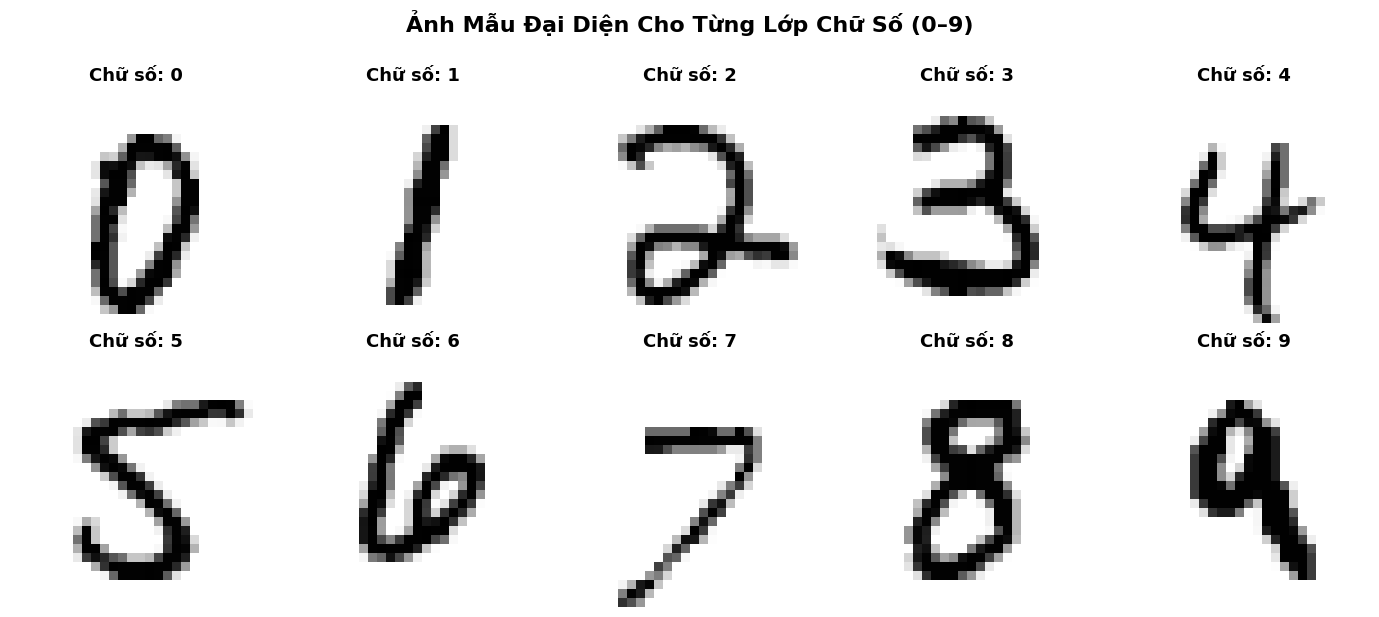

Đã lưu: assets/sample_grid.png


In [2]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Ảnh Mẫu Đại Diện Cho Từng Lớp Chữ Số (0–9)',
             fontsize=16, fontweight='bold', y=1.02)

for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    idx = np.where(Y_train == digit)[0][0]
    img = X_train[:, idx].reshape(28, 28)
    ax.imshow(img, cmap='gray_r', interpolation='nearest')
    ax.set_title(f'Chữ số: {digit}', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('../assets/sample_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu: assets/sample_grid.png')

## 2. Phân Bố Số Lượng Ảnh Theo Lớp (Class Distribution)

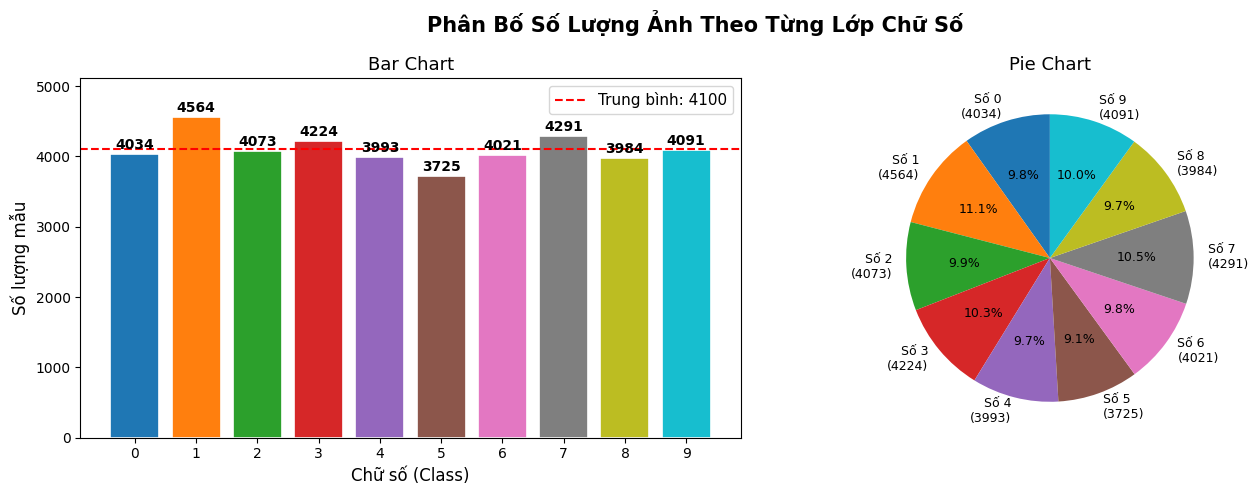

=== PHÂN TÍCH CÂN BẰNG DỮ LIỆU ===
Số lượng mẫu mỗi lớp: min=3725, max=4564, mean=4100
Tỷ lệ chênh lệch max/min: 1.23x
=> Dữ liệu CÂN BẰNG tốt (tỷ lệ < 1.5x). Không cần class weighting hay oversampling.


In [3]:
unique, counts = np.unique(Y_train, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân Bố Số Lượng Ảnh Theo Từng Lớp Chữ Số',
             fontsize=15, fontweight='bold')

# Bar chart
colors = plt.cm.tab10(np.linspace(0, 1, 10))
bars = axes[0].bar(unique, counts, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_xlabel('Chữ số (Class)', fontsize=12)
axes[0].set_ylabel('Số lượng mẫu', fontsize=12)
axes[0].set_title('Bar Chart', fontsize=13)
axes[0].set_xticks(range(10))
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(counts) * 1.12)
axes[0].axhline(y=np.mean(counts), color='red', linestyle='--',
                linewidth=1.5, label=f'Trung bình: {np.mean(counts):.0f}')
axes[0].legend(fontsize=11)

# Pie chart
axes[1].pie(counts, labels=[f'Số {d}\n({c})' for d, c in zip(unique, counts)],
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 9})
axes[1].set_title('Pie Chart', fontsize=13)

plt.tight_layout()
plt.savefig('../assets/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Nhận xét
print('=== PHÂN TÍCH CÂN BẰNG DỮ LIỆU ===')
print(f'Số lượng mẫu mỗi lớp: min={counts.min()}, max={counts.max()}, mean={counts.mean():.0f}')
print(f'Tỷ lệ chênh lệch max/min: {counts.max()/counts.min():.2f}x')
if counts.max() / counts.min() < 1.5:
    print('=> Dữ liệu CÂN BẰNG tốt (tỷ lệ < 1.5x). Không cần class weighting hay oversampling.')
else:
    print('=> Dữ liệu MẤT CÂN BẰNG. Cần xem xét class weighting hoặc oversampling.')

## 3. Tải Mô Hình & Chạy Dự Đoán

In [5]:
# --- Định nghĩa lại các hàm CNN (inference only) ---
def ReLU(Z): return np.maximum(Z, 0)

def im2col(X, fh, fw, stride=1, padding=0):
    if padding > 0:
        X = np.pad(X, ((0,0),(0,0),(padding,padding),(padding,padding)), 'constant')
    m, c, h, w = X.shape
    out_h = (h - fh) // stride + 1
    out_w = (w - fw) // stride + 1
    shape   = (m, c, out_h, out_w, fh, fw)
    strides = (X.strides[0], X.strides[1],
               X.strides[2]*stride, X.strides[3]*stride,
               X.strides[2], X.strides[3])
    return np.lib.stride_tricks.as_strided(X, shape=shape, strides=strides)

def conv2d_forward(X, W, b, stride=1, padding=0):
    f = W.shape[0]
    X_strided = im2col(X, W.shape[2], W.shape[3], stride, padding)
    Z = np.tensordot(X_strided, W, axes=([1,4,5],[1,2,3]))
    return np.transpose(Z, (0,3,1,2)) + b.reshape((1,f,1,1))

def maxpool_forward(X, pool_size=2):
    m, c, h, w = X.shape
    oh, ow = h // pool_size, w // pool_size
    return X[:,:,:oh*pool_size,:ow*pool_size].reshape(m,c,oh,pool_size,ow,pool_size).max(axis=(3,5))

def extract_features(X, model_data, batch_size=256):
    Wc1, bc1 = model_data['cnn']['Wc1'], model_data['cnn']['bc1']
    Wc2, bc2 = model_data['cnn']['Wc2'], model_data['cnn']['bc2']
    feats = []
    for j in range(0, X.shape[1], batch_size):
        Xb = X[:, j:j+batch_size]
        A0 = Xb.T.reshape(-1, 1, 28, 28)
        A1 = maxpool_forward(ReLU(conv2d_forward(A0, Wc1, bc1)))
        A2 = maxpool_forward(ReLU(conv2d_forward(A1, Wc2, bc2)))
        feats.append(A2.reshape(A2.shape[0], -1))
    return np.vstack(feats)

def predict_svm(features, model_data):
    scores = np.zeros((features.shape[0], 10))
    for c in range(10):
        w = model_data['svm'][c]['w']
        b = float(model_data['svm'][c]['b'])
        scores[:, c] = features @ w - b
    return np.argmax(scores, axis=1)

# Tải model và chạy predict
print('Tải mô hình...')
with open(MODEL_PATH, 'rb') as f:
    model_data = pickle.load(f)

print('Trích xuất đặc trưng CNN từ tập Validation...')
val_features = extract_features(X_val, model_data)
predictions  = predict_svm(val_features, model_data)

acc = np.mean(predictions == Y_val)
print(f'Accuracy trên Validation set: {acc*100:.2f}%')

Tải mô hình...
Trích xuất đặc trưng CNN từ tập Validation...
Accuracy trên Validation set: 97.90%


## 4. Confusion Matrix Heatmap

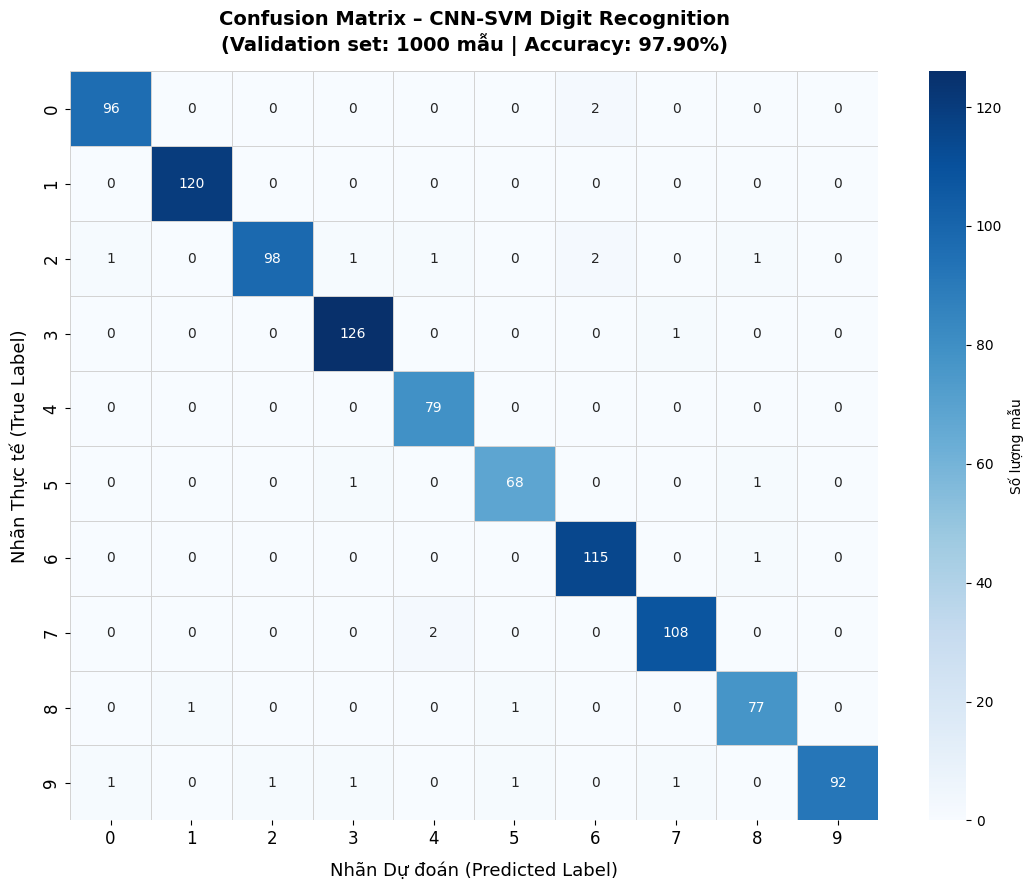


=== PHÂN TÍCH LỖI THEO LỚP ===
Số 0: hay nhầm thành số 6 (2 lần) | Recall = 98.0%
Số 2: hay nhầm thành số 6 (2 lần) | Recall = 94.2%
Số 3: hay nhầm thành số 7 (1 lần) | Recall = 99.2%
Số 5: hay nhầm thành số 3 (1 lần) | Recall = 97.1%
Số 6: hay nhầm thành số 8 (1 lần) | Recall = 99.1%
Số 7: hay nhầm thành số 4 (2 lần) | Recall = 98.2%
Số 8: hay nhầm thành số 1 (1 lần) | Recall = 97.5%
Số 9: hay nhầm thành số 0 (1 lần) | Recall = 94.8%


In [7]:
# Tính Confusion Matrix
cm = np.zeros((10, 10), dtype=int)
for t, p in zip(Y_val, predictions):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='lightgray',
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Số lượng mẫu'},
            ax=ax)

ax.set_xlabel('Nhãn Dự đoán (Predicted Label)', fontsize=13, labelpad=10)
ax.set_ylabel('Nhãn Thực tế (True Label)',       fontsize=13, labelpad=10)
ax.set_title('Confusion Matrix – CNN-SVM Digit Recognition\n'
             f'(Validation set: 1000 mẫu | Accuracy: {acc*100:.2f}%)',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig('../assets/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Phân tích lỗi
print('\n=== PHÂN TÍCH LỖI THEO LỚP ===')
for i in range(10):
    errors = [(j, cm[i,j]) for j in range(10) if j != i and cm[i,j] > 0]
    errors.sort(key=lambda x: -x[1])
    if errors:
        top = errors[0]
        print(f'Số {i}: hay nhầm thành số {top[0]} ({top[1]} lần) | '
              f'Recall = {cm[i,i]/cm[i,:].sum()*100:.1f}%')

## 5. Trực Quan Hóa Dự Đoán (Đúng & Sai)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19352\2865759238.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('../assets/prediction_samples.png', dpi=150, bbox_inches='tight')
C:\Users\Admin\AppData\Local\Temp\ipykernel_19352\2865759238.py:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('../assets/prediction_samples.png', dpi=150, bbox_inches='tight')
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


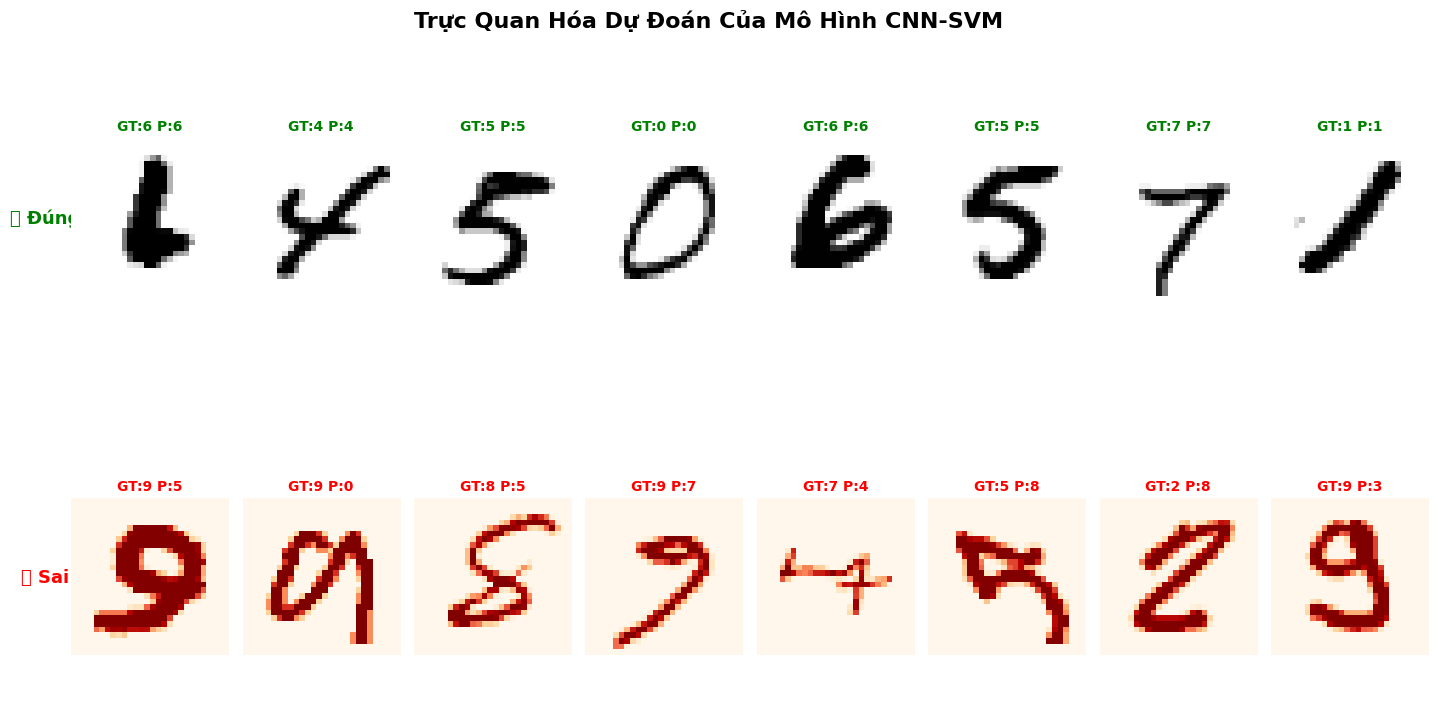

Đoán sai: 21/1000 mẫu (2.1%)


In [8]:
correct_idx   = np.where(predictions == Y_val)[0]
incorrect_idx = np.where(predictions != Y_val)[0]

n_show = 8
fig = plt.figure(figsize=(18, 8))
fig.suptitle('Trực Quan Hóa Dự Đoán Của Mô Hình CNN-SVM',
             fontsize=16, fontweight='bold')

gs = gridspec.GridSpec(2, n_show + 1, width_ratios=[0.15]+[1]*n_show,
                       hspace=0.4, wspace=0.1)

# Label cột trái
ax_lbl1 = fig.add_subplot(gs[0, 0])
ax_lbl1.text(0.5, 0.5, '✅ Đúng', ha='center', va='center',
             fontsize=13, fontweight='bold', color='green',
             transform=ax_lbl1.transAxes)
ax_lbl1.axis('off')

ax_lbl2 = fig.add_subplot(gs[1, 0])
ax_lbl2.text(0.5, 0.5, '❌ Sai', ha='center', va='center',
             fontsize=13, fontweight='bold', color='red',
             transform=ax_lbl2.transAxes)
ax_lbl2.axis('off')

# Hàng 1: Dự đoán ĐÚNG
sample_correct = np.random.choice(correct_idx, n_show, replace=False)
for col, idx in enumerate(sample_correct):
    ax = fig.add_subplot(gs[0, col+1])
    ax.imshow(X_val[:, idx].reshape(28,28), cmap='gray_r')
    ax.set_title(f'GT:{Y_val[idx]} P:{predictions[idx]}',
                 color='green', fontsize=10, fontweight='bold')
    ax.axis('off')

# Hàng 2: Dự đoán SAI
n_wrong = min(n_show, len(incorrect_idx))
sample_wrong = incorrect_idx[:n_wrong]
for col, idx in enumerate(sample_wrong):
    ax = fig.add_subplot(gs[1, col+1])
    ax.imshow(X_val[:, idx].reshape(28,28), cmap='OrRd')
    ax.set_title(f'GT:{Y_val[idx]} P:{predictions[idx]}',
                 color='red', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.savefig('../assets/prediction_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Đoán sai: {len(incorrect_idx)}/{len(Y_val)} mẫu ({len(incorrect_idx)/len(Y_val)*100:.1f}%)')

## 6. Tổng Hợp Kết Quả (Summary)

In [11]:
# Tính metrics từng lớp
print('=' * 55)
print(f'{"CLASS":<8} {"PRECISION":>10} {"RECALL":>10} {"F1":>10}')
print('-' * 55)
precisions, recalls, f1s = [], [], []
for c in range(10):
    TP = cm[c, c]
    FP = cm[:, c].sum() - TP
    FN = cm[c, :].sum() - TP
    p  = TP / (TP+FP) if TP+FP > 0 else 0
    r  = TP / (TP+FN) if TP+FN > 0 else 0
    f1 = 2*p*r/(p+r) if p+r > 0 else 0
    precisions.append(p); recalls.append(r); f1s.append(f1)
    print(f'Số {c:<5} {p:>10.4f} {r:>10.4f} {f1:>10.4f}')
print('=' * 55)
mp, mr, mf = np.mean(precisions), np.mean(recalls), np.mean(f1s)
print(f'{"MACRO AVG":<8} {mp:>10.4f} {mr:>10.4f} {mf:>10.4f}')
print(f'\nAccuracy tổng thể : {acc*100:.2f}%')
print(f'Macro F1-Score    : {mf:.4f}')
print('\n=> Các file ảnh đã lưu vào thư mục assets/')

CLASS     PRECISION     RECALL         F1
-------------------------------------------------------
Số 0         0.9796     0.9796     0.9796
Số 1         0.9917     1.0000     0.9959
Số 2         0.9899     0.9423     0.9655
Số 3         0.9767     0.9921     0.9844
Số 4         0.9634     1.0000     0.9814
Số 5         0.9714     0.9714     0.9714
Số 6         0.9664     0.9914     0.9787
Số 7         0.9818     0.9818     0.9818
Số 8         0.9625     0.9747     0.9686
Số 9         1.0000     0.9485     0.9735
MACRO AVG     0.9784     0.9782     0.9781

Accuracy tổng thể : 97.90%
Macro F1-Score    : 0.9781

=> Các file ảnh đã lưu vào thư mục assets/
